# Phase 2 — Prédiction de Trajectoire
## Simulateur Iron Dome — PFA ENSTAB
### Filtre de Kalman + Machine Learning


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
import sys
sys.path.append('../src')
from simulation.rocket import RocketRK4, ThreatGenerator

## 1. Simulation du Radar
Avant de prédire, il faut simuler ce que le radar "voit" :
- Le radar mesure la position de la roquette à intervalles réguliers
- Chaque mesure contient du **bruit** (imprécision du capteur)
- On ne voit que les **k premiers points** (pas toute la trajectoire)

In [2]:
class Radar:
    """
    Simule un radar de détection qui observe une roquette.
    Retourne des mesures bruitées à intervalles réguliers.
    """
    
    def __init__(self, sigma=30, frequence=10):
        """
        Paramètres :
        - sigma     : écart-type du bruit de mesure (m)
        - frequence : nombre de mesures par seconde (Hz)
        """
        self.sigma = sigma
        self.frequence = frequence
        self.dt_mesure = 1.0 / frequence
    
    def observer(self, t_vrai, x_vrai, y_vrai, duree_observation=3.0):
        """
        Observe la trajectoire pendant une durée limitée.
        
        Paramètres :
        - t_vrai, x_vrai, y_vrai : trajectoire réelle complète
        - duree_observation       : combien de secondes on observe (s)
        
        Retourne :
        - t_obs, x_obs, y_obs : mesures bruitées
        - t_vrai_obs, x_vrai_obs, y_vrai_obs : positions réelles correspondantes
        """
        # Sélectionner les points dans la fenêtre d'observation
        masque = t_vrai <= duree_observation
        t_obs_base = t_vrai[masque]
        x_obs_base = x_vrai[masque]
        y_obs_base = y_vrai[masque]
        
        # Sous-échantillonner selon la fréquence du radar
        indices = np.arange(0, len(t_obs_base), 
                           max(1, int(1.0 / (self.frequence * 0.1))))
        
        t_obs = t_obs_base[indices]
        x_vrai_obs = x_obs_base[indices]
        y_vrai_obs = y_obs_base[indices]
        
        # Ajouter le bruit de mesure
        x_obs = x_vrai_obs + np.random.normal(0, self.sigma, len(t_obs))
        y_obs = y_vrai_obs + np.random.normal(0, self.sigma, len(t_obs))
        y_obs = np.maximum(y_obs, 0)  # pas sous le sol
        
        return {
            't': t_obs,
            'x': x_obs,
            'y': y_obs,
            'x_vrai': x_vrai_obs,
            'y_vrai': y_vrai_obs,
            'n_mesures': len(t_obs)
        }

Nombre de mesures radar : 81
Duree observation       : 8.0 s
Duree totale vol        : 40.5 s
Pourcentage observe     : 20%


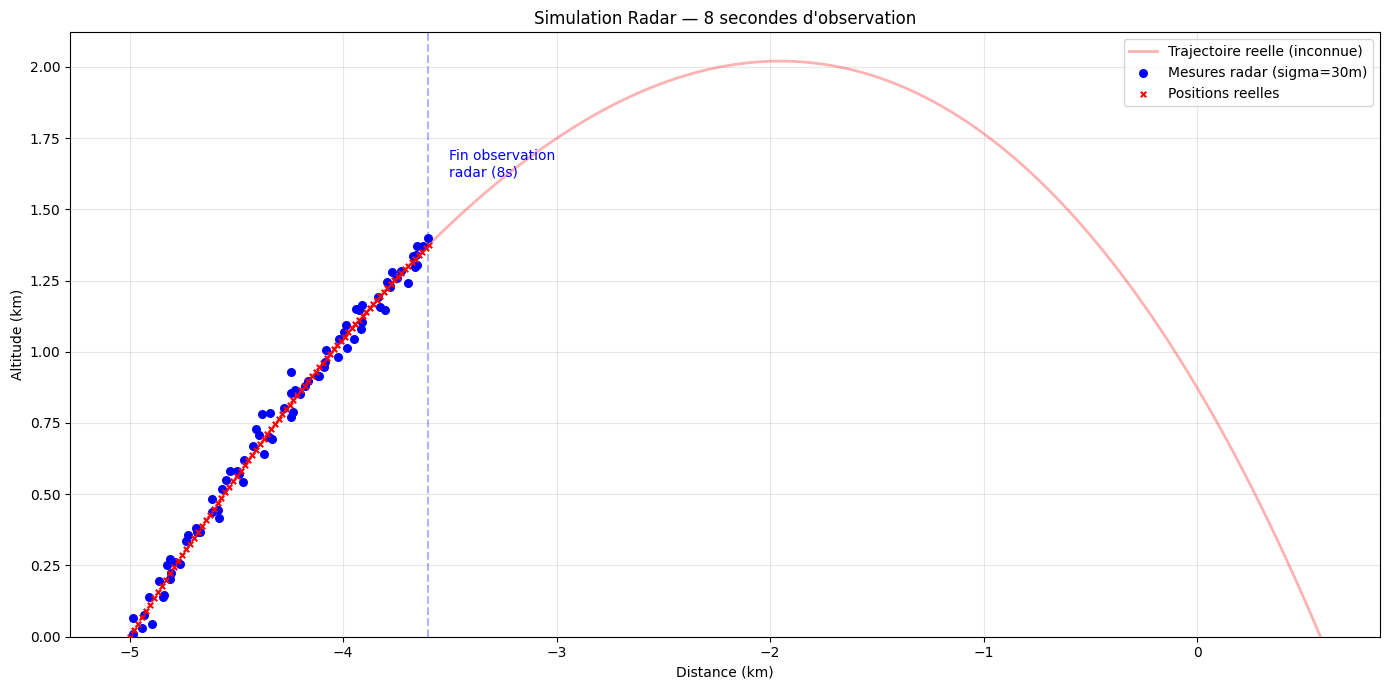

In [3]:
# Créer une roquette
roquette = RocketRK4(v0=300, angle_deg=50, masse=100, Cd=0.3, A=0.05,
                      x0=-5000, y0=0)
t_vrai, x_vrai, y_vrai = roquette.trajectoire_rk4(dt=0.1)

# Simuler le radar (observe les 8 premières secondes)
np.random.seed(42)
radar = Radar(sigma=30, frequence=10)
mesures = radar.observer(t_vrai, x_vrai, y_vrai, duree_observation=8.0)

print(f"Nombre de mesures radar : {mesures['n_mesures']}")
print(f"Duree observation       : {mesures['t'][-1]:.1f} s")
print(f"Duree totale vol        : {t_vrai[-1]:.1f} s")
print(f"Pourcentage observe     : {mesures['t'][-1]/t_vrai[-1]*100:.0f}%")

# Visualisation
fig, ax = plt.subplots(figsize=(14, 7))

# Trajectoire réelle complète
ax.plot(x_vrai/1000, y_vrai/1000, 'r-', linewidth=2, alpha=0.3,
        label='Trajectoire reelle (inconnue)')

# Points radar bruités
ax.scatter(mesures['x']/1000, mesures['y']/1000, c='blue', s=30, zorder=5,
           label=f'Mesures radar (sigma={radar.sigma}m)')

# Points réels correspondants
ax.scatter(mesures['x_vrai']/1000, mesures['y_vrai']/1000, c='red', s=15,
           marker='x', zorder=5, label='Positions reelles')

# Zone observée vs inconnue
ax.axvline(x=mesures['x'][-1]/1000, color='blue', linestyle='--', alpha=0.3)
ax.text(mesures['x'][-1]/1000 + 0.1, max(y_vrai/1000)*0.8,
        'Fin observation\nradar (8s)', fontsize=10, color='blue')

ax.set_xlabel('Distance (km)')
ax.set_ylabel('Altitude (km)')
ax.set_title('Simulation Radar — 8 secondes d\'observation')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## 2. Extended Kalman Filter (EKF)
### Principe
Contrairement au Kalman lineaire, l'EKF utilise un **modele non-lineaire** qui integre
directement le drag dans les equations. Le drag est estime conjointement avec la position et la vitesse.

Etat du systeme : $\\vec{x} = [x, y, v_x, v_y, k_{drag}]^T$ (5 dimensions)

Le coefficient de drag $k_{drag}$ est estime automatiquement par le filtre.
C'est la meme approche que les vrais systemes de defense anti-missile.


In [4]:
import scipy.linalg as linalg

class KalmanFilter:
    """
    Unscented Kalman Filter (UKF) pour suivi et prediction de trajectoire balistique.
    
    Estime dynamiquement le vecteur d'etat [x, y, vx, vy, k] ou k est le 
    coefficient de trainee balistique (drag). L'UKF utilise la propagation
    par points sigma, eliminant le besoin de Jacobiennes et augmentant la
    precision sur la non-linearite du vol.
    """
    
    def __init__(self, sigma_processus=5.0, sigma_mesure=30.0):
        self.g = 9.81
        self.sigma_processus = sigma_processus
        self.sigma_mesure = sigma_mesure
        self.k_drag_init = 0.000086
        
        # Dimensions
        self.n = 5
        
        # Parametres Merwe Scaled Sigma Points
        self.alpha = 1e-3
        self.beta = 2
        self.kappa = 0
        self.lam = self.alpha**2 * (self.n + self.kappa) - self.n
        
        # Poids
        self.Wm = np.zeros(2 * self.n + 1)
        self.Wc = np.zeros(2 * self.n + 1)
        
        self.Wm[0] = self.lam / (self.n + self.lam)
        self.Wc[0] = self.lam / (self.n + self.lam) + (1 - self.alpha**2 + self.beta)
        for i in range(1, 2 * self.n + 1):
            self.Wm[i] = 1.0 / (2 * (self.n + self.lam))
            self.Wc[i] = 1.0 / (2 * (self.n + self.lam))

    def _generer_points_sigma(self, x, P):
        try:
            U = linalg.cholesky((self.n + self.lam) * P)
        except linalg.LinAlgError:
            U = linalg.cholesky((self.n + self.lam) * (P + np.eye(self.n) * 1e-8))
            
        sigmas = np.zeros((2 * self.n + 1, self.n))
        sigmas[0] = x
        for k in range(self.n):
            sigmas[k + 1] = x + U[k]
            sigmas[self.n + k + 1] = x - U[k]
        return sigmas

    def _derivees(self, state, k):
        """Calcule les derivees pour RK4 : [vx, vy, ax, ay]."""
        x, y, vx, vy = state
        v = np.sqrt(vx**2 + vy**2)
        if v > 0 and k > 0:
            ax = -k * v * vx
            ay = -self.g - k * v * vy
        else:
            ax = 0
            ay = -self.g
        return np.array([vx, vy, ax, ay])
        
    def _rk4_step(self, X, dt):
        """Propage l'etat [x, y, vx, vy, k] sur dt via RK4."""
        x, y, vx, vy, k = X
        state = np.array([x, y, vx, vy])
        k1 = self._derivees(state, k)
        k2 = self._derivees(state + dt/2 * k1, k)
        k3 = self._derivees(state + dt/2 * k2, k)
        k4 = self._derivees(state + dt * k3, k)
        
        new_state = state + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)
        return np.array([new_state[0], new_state[1], new_state[2], new_state[3], k])

    def filtrer(self, t_obs, x_obs, y_obs):
        if len(t_obs) < 2:
            return np.array([[x_obs[0], y_obs[0], 0, 0, self.k_drag_init]])

        dt = t_obs[1] - t_obs[0]
        K_SCALE = 10000.0
        
        # Initialisation robuste pour la Vitesse
        n_init = min(5, len(t_obs))
        vx0 = np.polyfit(t_obs[:n_init], x_obs[:n_init], 1)[0]
        vy0 = np.polyfit(t_obs[:n_init], y_obs[:n_init], 1)[0]
        X = np.array([x_obs[0], y_obs[0], vx0, vy0, self.k_drag_init * K_SCALE])
        
        P = np.diag([
            self.sigma_mesure**2, self.sigma_mesure**2,
            (self.sigma_mesure)**2, (self.sigma_mesure)**2,
            0.5**2
        ])
        
        # On FOCUS sur la vitesse (Q tres petit = vitesse ultra lisse)
        # Et on donne moins d'importance a k (Q tres petit = k ne bouge presque pas)
        sigma_a = 2.0  # La vitesse doit suivre une physique propre
        Q = np.diag([
            (0.5 * sigma_a * dt**2)**2, (0.5 * sigma_a * dt**2)**2,
            (sigma_a * dt)**2, (sigma_a * dt)**2,
            0.01**2  # k est bloque, il n'a pas le droit d'absorber le bruit
        ])
        R = np.eye(2) * self.sigma_mesure**2
        
        etats = []
        for j in range(len(t_obs)):
            # --- PREDICTION UKF ---
            sigmas = self._generer_points_sigma(X, P)
            sigmas_f = np.zeros_like(sigmas)
            
            for i in range(2 * self.n + 1):
                state_physique = sigmas[i].copy()
                state_physique[4] /= K_SCALE
                
                state_pred = self._rk4_step(state_physique, dt)
                
                state_pred[4] *= K_SCALE
                sigmas_f[i] = state_pred
                
            X_pred = np.dot(self.Wm, sigmas_f)
            
            P_pred = Q.copy()
            for i in range(2 * self.n + 1):
                y_diff = sigmas_f[i] - X_pred
                P_pred += self.Wc[i] * np.outer(y_diff, y_diff)
                
            # --- MISE A JOUR UKF ---
            sigmas_h = np.zeros((2 * self.n + 1, 2))
            for i in range(2 * self.n + 1):
                sigmas_h[i] = [sigmas_f[i, 0], sigmas_f[i, 1]]
                
            zp = np.dot(self.Wm, sigmas_h)
            
            S = R.copy()
            for i in range(2 * self.n + 1):
                y_diff = sigmas_h[i] - zp
                S += self.Wc[i] * np.outer(y_diff, y_diff)
                
            Pxz = np.zeros((self.n, 2))
            for i in range(2 * self.n + 1):
                Pxz += self.Wc[i] * np.outer(sigmas_f[i] - X_pred, sigmas_h[i] - zp)
                
            K_gain = np.dot(Pxz, linalg.inv(S))
            z_obs = np.array([x_obs[j], y_obs[j]])
            
            X = X_pred + np.dot(K_gain, z_obs - zp)
            P = P_pred - np.dot(K_gain, np.dot(S, K_gain.T))
            
            X[4] = np.clip(X[4], 0.1, 8.0)
            
            etat = X.copy()
            etat[4] = etat[4] / K_SCALE
            etats.append(etat)
            
        return np.array(etats)

    def _simuler_trajectoire(self, etat, force_k=None, dt=0.01):
        if len(etat) == 5:
            x, y, vx, vy, k = etat
        else:
            x, y, vx, vy = etat
            k = self.k_drag_init
            
        if force_k is not None:
            k = force_k
            
        state = np.array([x, y, vx, vy], dtype=float)
        preds = [state.copy()]

        for _ in range(50000):
            k1 = self._derivees(state, k)
            k2 = self._derivees(state + dt/2 * k1, k)
            k3 = self._derivees(state + dt/2 * k2, k)
            k4 = self._derivees(state + dt * k3, k)
            
            new_state = state + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)

            if new_state[1] < 0 and state[1] >= 0:
                frac = state[1] / (state[1] - new_state[1])
                x_impact = state[0] + frac * (new_state[0] - state[0])
                preds.append(np.array([x_impact, 0, 0, 0]))
                break
            
            state = new_state
            preds.append(state.copy())
            
            if state[1] < -100:
                break

        return np.array(preds)

    def pipeline_complet(self, t_obs, x_obs, y_obs):
        etats = self.filtrer(t_obs, x_obs, y_obs)
        etat_final = etats[-1]
        k_estime = etat_final[4]

        preds_brut = self._simuler_trajectoire(etat_final, force_k=0)
        preds_drag = self._simuler_trajectoire(etat_final, force_k=k_estime)

        return {
            'etats_filtres': etats,
            'predictions_brutes': preds_brut,
            'predictions': preds_drag,
            'x_impact_brut': preds_brut[-1][0],
            'x_impact': preds_drag[-1][0],
            'k_estime': k_estime
        }



In [5]:
# Appliquer l'Extended Kalman Filter
kf = KalmanFilter(sigma_processus=5.0, sigma_mesure=radar.sigma)
resultat_kf = kf.pipeline_complet(mesures['t'], mesures['x'], mesures['y'])

etats_filtres = resultat_kf['etats_filtres']
predictions = resultat_kf['predictions']

# Drag reel (pour comparaison)
k_reel = 0.5 * 1.225 * 0.3 * 0.05 / 100

print(f"Mesures traitees       : {len(mesures['t'])}")
print(f"")
print(f"Drag reel (inconnu)    : k = {k_reel:.6f}")
print(f"Drag estime (EKF)     : k = {resultat_kf['k_estime']:.6f}")
if k_reel > 0:
    print(f"Ratio estime/reel      : {resultat_kf['k_estime']/k_reel:.2f}")
print(f"")
print(f"Point d'impact brut    : x = {resultat_kf['x_impact_brut']:.0f} m (sans drag)")
print(f"Point d'impact EKF     : x = {resultat_kf['x_impact']:.0f} m (drag estime)")
print(f"Point d'impact reel    : x = {x_vrai[-1]:.0f} m")
print(f"")
print(f"Erreur sans drag       : {abs(resultat_kf['x_impact_brut'] - x_vrai[-1]):.0f} m")
print(f"Erreur EKF             : {abs(resultat_kf['x_impact'] - x_vrai[-1]):.0f} m")

Mesures traitees       : 81

Drag reel (inconnu)    : k = 0.000092
Drag estime (EKF)     : k = 0.000059
Ratio estime/reel      : 0.65

Point d'impact brut    : x = 1974 m (sans drag)
Point d'impact EKF     : x = 1099 m (drag estime)
Point d'impact reel    : x = 578 m

Erreur sans drag       : 1396 m
Erreur EKF             : 521 m


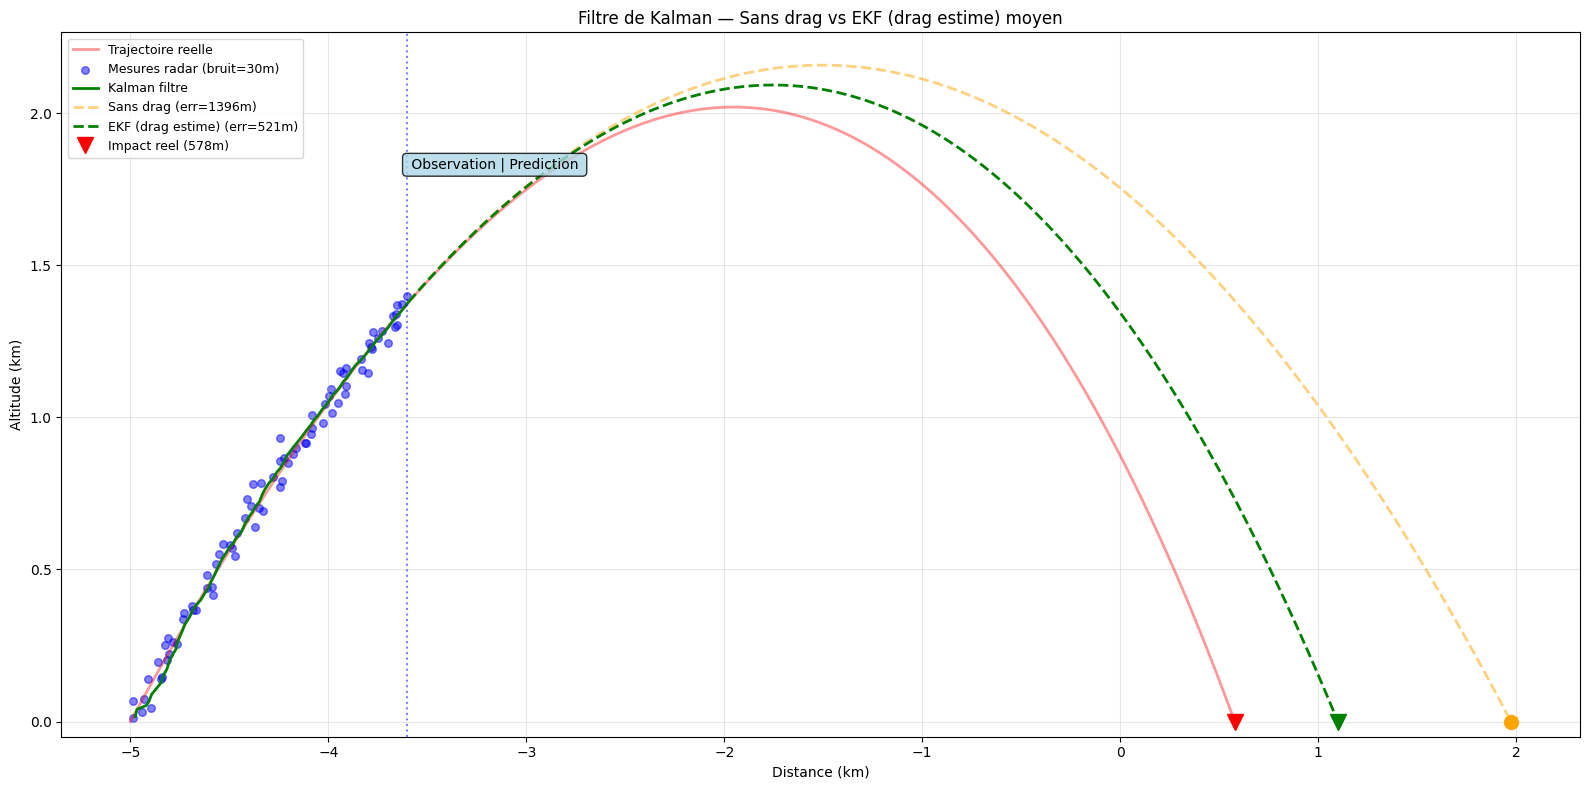

In [6]:
fig, ax = plt.subplots(figsize=(16, 8))

# Trajectoire réelle
ax.plot(x_vrai/1000, y_vrai/1000, 'r-', linewidth=2, alpha=0.4, label='Trajectoire reelle')

# Mesures radar
ax.scatter(mesures['x']/1000, mesures['y']/1000, c='blue', s=30, alpha=0.5,
           label=f'Mesures radar (bruit={radar.sigma}m)')

# Kalman filtré
ax.plot(etats_filtres[:, 0]/1000, etats_filtres[:, 1]/1000,
        'g-', linewidth=2, label='Kalman filtre')

# Prédiction BRUTE (sans drag)
preds_b = resultat_kf['predictions_brutes']
ax.plot(preds_b[:, 0]/1000, preds_b[:, 1]/1000,
        color='orange', linestyle='--', linewidth=2, alpha=0.5,
        label=f'Sans drag (err={abs(resultat_kf["x_impact_brut"]-x_vrai[-1]):.0f}m)')

# Prédiction AMÉLIORÉE (avec drag)
ax.plot(predictions[:, 0]/1000, predictions[:, 1]/1000,
        'g--', linewidth=2,
        label=f'EKF (drag estime) (err={abs(resultat_kf["x_impact"]-x_vrai[-1]):.0f}m)')

# Points d'impact
ax.plot(resultat_kf['x_impact_brut']/1000, 0, 'o', color='orange', markersize=10)
ax.plot(resultat_kf['x_impact']/1000, 0, 'gv', markersize=12)
ax.plot(x_vrai[-1]/1000, 0, 'rv', markersize=12, label=f'Impact reel ({x_vrai[-1]:.0f}m)')

# Séparation
ax.axvline(x=mesures['x'][-1]/1000, color='blue', linestyle=':', alpha=0.5)
ax.text(mesures['x'][-1]/1000, max(y_vrai/1000)*0.9,
        ' Observation | Prediction ', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

ax.set_xlabel('Distance (km)')
ax.set_ylabel('Altitude (km)')
ax.set_title('Filtre de Kalman — Sans drag vs EKF (drag estime) moyen')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=-0.05)
plt.tight_layout()
plt.show()

## 3. Machine Learning — Régression Polynomiale
### Approche
On utilise les k points observés par le radar pour ajuster un polynôme
et prédire la trajectoire future.

**Entrée** : positions (t, x, y) observées par le radar  
**Sortie** : trajectoire complète prédite et point d'impact

In [7]:
class PolynomialPredictor:
    """
    Prédit la trajectoire future par régression polynomiale.
    - x(t) → polynôme degré 1 (mouvement quasi-linéaire en x)
    - y(t) → polynôme degré 2 (parabole due à la gravité)
    """
    
    def __init__(self, deg_x=2, deg_y=2):
        self.deg_x = deg_x
        self.deg_y = deg_y
        self.coeff_x = None
        self.coeff_y = None
    
    def entrainer(self, t_obs, x_obs, y_obs):
        """Ajuste les polynômes sur les observations."""
        self.coeff_x = np.polyfit(t_obs, x_obs, self.deg_x)
        self.coeff_y = np.polyfit(t_obs, y_obs, self.deg_y)
    
    def predire(self, t_futur):
        """Prédit x(t) et y(t) pour des temps futurs."""
        x_pred = np.polyval(self.coeff_x, t_futur)
        y_pred = np.polyval(self.coeff_y, t_futur)
        return x_pred, y_pred
    
    def predire_trajectoire(self, t_obs, x_obs, y_obs, dt=0.1):
        """
        Entraîne puis prédit la trajectoire complète
        jusqu'à l'impact au sol.
        """
        self.entrainer(t_obs, x_obs, y_obs)
        
        # Générer les temps futurs
        t_max = t_obs[-1] * 10  # marge large
        t_futur = np.arange(t_obs[0], t_max, dt)
        
        x_pred, y_pred = self.predire(t_futur)
        
        # Trouver le point d'impact (y = 0)
        idx_impact = np.where(y_pred < 0)[0]
        if len(idx_impact) > 0:
            idx = idx_impact[0]
            t_futur = t_futur[:idx+1]
            x_pred = x_pred[:idx+1]
            y_pred = y_pred[:idx+1]
            y_pred[-1] = 0
        
        return t_futur, x_pred, y_pred


# Tester avec les mesures radar
poly = PolynomialPredictor(deg_x=2, deg_y=2)
t_pred_poly, x_pred_poly, y_pred_poly = poly.predire_trajectoire(
    mesures['t'], mesures['x'], mesures['y'], dt=0.1
)

print(f"Impact predit (poly) : x = {x_pred_poly[-1]:.0f} m")
print(f"Impact reel          : x = {x_vrai[-1]:.0f} m")
print(f"Erreur               : {abs(x_pred_poly[-1] - x_vrai[-1]):.0f} m")

Impact predit (poly) : x = -167 m
Impact reel          : x = 578 m
Erreur               : 745 m


## 4. Machine Learning — LSTM (Long Short-Term Memory) avec PyTorch
On entraîne un réseau LSTM sur des milliers de trajectoires
générées par notre simulateur physique.

**Entrée** : séquences temporelles (x, y, vx, vy) observées  
**Sortie** : point d'impact prédit (x_impact)

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import copy

def generer_dataset_sequences(n_trajectoires=18000, n_points_obs=40, sigma=30, seed=42):
    """
    Dataset de sequences temporelles pour LSTM.
    Chaque sample est une sequence de (x, y, vx, vy) a chaque pas de temps.
    """
    np.random.seed(seed)
    sequences = []
    targets = []

    for i in range(n_trajectoires):
        v0 = np.random.uniform(150, 400)
        angle = np.random.uniform(30, 75)
        masse = np.random.uniform(50, 200)
        Cd = np.random.uniform(0.2, 0.5)
        x0 = np.random.uniform(-8000, -3000)

        r = RocketRK4(v0=v0, angle_deg=angle, masse=masse, Cd=Cd, x0=x0, y0=0)
        t_v, x_v, y_v = r.trajectoire_rk4(dt=0.1)

        if len(t_v) < n_points_obs + 5:
            continue

        t_obs = t_v[:n_points_obs]
        x_obs = x_v[:n_points_obs] + np.random.normal(0, sigma, n_points_obs)
        y_obs = np.maximum(y_v[:n_points_obs] + np.random.normal(0, sigma, n_points_obs), 0)
        dt_r = t_obs[1] - t_obs[0]

        # Calculer vitesses
        vx = np.gradient(x_obs, dt_r)
        vy = np.gradient(y_obs, dt_r)

        # Sequence : a chaque pas de temps -> (x, y, vx, vy)
        seq = np.column_stack([
            x_obs / 1000.0,   # positions x normalisees (km)
            y_obs / 1000.0,   # positions y normalisees (km)
            vx / 100.0,       # vitesses x normalisees
            vy / 100.0        # vitesses y normalisees
        ])

        sequences.append(seq)
        targets.append(x_v[-1] / 1000.0)  # impact en km

    return np.array(sequences), np.array(targets)

print("Generation du dataset de sequences (18000 trajectoires, 40 pas de temps)...")
X_seq, y_seq = generer_dataset_sequences(n_trajectoires=18000, n_points_obs=40, sigma=30)
print(f"Dataset : {X_seq.shape[0]} trajectoires, sequences de forme {X_seq.shape[1:]}")

# Normaliser les features par dimension
n_samples, n_steps, n_features = X_seq.shape
X_flat = X_seq.reshape(-1, n_features)
seq_scaler = StandardScaler()
X_scaled = seq_scaler.fit_transform(X_flat).reshape(n_samples, n_steps, n_features)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y_seq.reshape(-1, 1)).ravel()

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42)
print(f"Train : {len(X_train)}, Test : {len(X_test)}")

Generation du dataset de sequences (18000 trajectoires, 40 pas de temps)...


KeyboardInterrupt: 

In [ ]:
# Definition du modele LSTM en PyTorch
class RocketLSTM(nn.Module):
    def __init__(self, input_size, hidden_size1=128, hidden_size2=64):
        super(RocketLSTM, self).__init__()
        self.lstm1 = nn.LSTM(input_size, hidden_size1, batch_first=True)
        self.dropout1 = nn.Dropout(0.2)
        self.lstm2 = nn.LSTM(hidden_size1, hidden_size2, batch_first=True)
        self.dropout2 = nn.Dropout(0.2)
        self.fc1 = nn.Linear(hidden_size2, 64)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.out = nn.Linear(32, 1)

    def forward(self, x):
        x, _ = self.lstm1(x)
        x = self.dropout1(x)
        x, _ = self.lstm2(x)
        # On ne garde que la derniere sortie de la sequence
        x = x[:, -1, :]
        x = self.dropout2(x)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.out(x)
        return x

print("Construction et entrainement du modele LSTM (PyTorch)...")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Appareil utilise : {device}")

# Conversion en tenseurs PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

# Validation split
n_val = int(len(X_train) * 0.15)
X_val_t = X_train_t[-n_val:]
y_val_t = y_train_t[-n_val:]
X_train_t = X_train_t[:-n_val]
y_train_t = y_train_t[:-n_val]

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

model = RocketLSTM(input_size=X_train.shape[2]).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Entrainement avec early stopping
patience = 15
best_val_loss = float('inf')
best_weights = None
patience_counter = 0
epochs = 100

print("Début de l'entraînement...")
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch_X.size(0)
    
    train_loss /= len(train_loader.dataset)
    
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_t)
        val_loss = criterion(val_outputs, y_val_t).item()
        
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{epochs} - loss: {train_loss:.4f} - val_loss: {val_loss:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping a l'epoch {epoch+1} (meilleure val_loss: {best_val_loss:.4f})")
            break

# Restauration des meilleurs poids
if best_weights:
    model.load_state_dict(best_weights)

# Evaluation
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test_t).cpu().numpy()

y_pred = scaler_y.inverse_transform(y_pred_scaled).ravel() * 1000
y_test_m = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel() * 1000

mae = mean_absolute_error(y_test_m, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_m, y_pred))
r2 = r2_score(y_test_m, y_pred)

print(f"\nResultats du LSTM :")
print(f"  MAE  : {mae:.1f} m")
print(f"  RMSE : {rmse:.1f} m")
print(f"  R2   : {r2:.4f}")
print(f"\n  18000 trajectoires, 40 pas de temps (8s)")
print(f"  Architecture : LSTM(128) -> LSTM(64) -> Dense(64) -> Dense(32) -> Dense(1)")

Construction et entrainement du modele LSTM (PyTorch)...
Appareil utilise : cpu
Début de l'entraînement...
Epoch 1/100 - loss: 0.1651 - val_loss: 0.0813
Epoch 10/100 - loss: 0.0660 - val_loss: 0.0813
Epoch 20/100 - loss: 0.0615 - val_loss: 0.0605
Epoch 30/100 - loss: 0.0579 - val_loss: 0.0564
Epoch 40/100 - loss: 0.0545 - val_loss: 0.0686
Early stopping a l'epoch 41 (meilleure val_loss: 0.0545)

Resultats du LSTM :
  MAE  : 413.9 m
  RMSE : 559.8 m
  R2   : 0.9465

  18000 trajectoires, 40 pas de temps (8s)
  Architecture : LSTM(128) -> LSTM(64) -> Dense(64) -> Dense(32) -> Dense(1)


In [ ]:
# === Impact de la duree d'observation sur le LSTM ===
print("=== Impact du nombre de trajectoires et de pas de temps ===\n")
print("(Note : l'entrainement LSTM prend plus de temps que le MLP)\n")

configs = [
    (3000, 20, 30, "3000 traj, 20 pts (4s)"),
    (5000, 30, 30, "5000 traj, 30 pts (6s)"),
    (8000, 40, 30, "8000 traj, 40 pts (8s)"),
    (8000, 40, 15, "8000 traj, 40 pts, bruit=15m"),
]

for n_traj, n_pts, sigma, desc in configs:
    X_t, y_t = generer_dataset_sequences(
        n_trajectoires=n_traj, n_points_obs=n_pts, sigma=sigma)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_t, y_t, test_size=0.2, random_state=42)

    # Normaliser
    ns, nt, nf = X_tr.shape
    sc_X = StandardScaler()
    X_tr_s = sc_X.fit_transform(X_tr.reshape(-1, nf)).reshape(ns, nt, nf)
    ns2 = X_te.shape[0]
    X_te_s = sc_X.transform(X_te.reshape(-1, nf)).reshape(ns2, nt, nf)
    sc_y = StandardScaler()
    y_tr_s = sc_y.fit_transform(y_tr.reshape(-1, 1)).ravel()

    # PyTorch Tensors
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    X_tr_t = torch.tensor(X_tr_s, dtype=torch.float32).to(device)
    y_tr_t = torch.tensor(y_tr_s, dtype=torch.float32).view(-1, 1).to(device)
    X_te_t = torch.tensor(X_te_s, dtype=torch.float32).to(device)

    # Simple validation split
    n_val = int(len(X_tr_s) * 0.15)
    X_v_t = X_tr_t[-n_val:]
    y_v_t = y_tr_t[-n_val:]
    X_tr_t = X_tr_t[:-n_val]
    y_tr_t = y_tr_t[:-n_val]

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)

    model_exp = RocketLSTM(input_size=nf).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model_exp.parameters(), lr=0.001)

    best_val_loss = float('inf')
    best_weights = None
    pat_count = 0

    for epoch in range(60):
        model_exp.train()
        for b_X, b_y in loader:
            optimizer.zero_grad()
            loss = criterion(model_exp(b_X), b_y)
            loss.backward()
            optimizer.step()
        
        model_exp.eval()
        with torch.no_grad():
            v_loss = criterion(model_exp(X_v_t), y_v_t).item()
        
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            best_weights = copy.deepcopy(model_exp.state_dict())
            pat_count = 0
        else:
            pat_count += 1
            if pat_count >= 10:
                break
    
    if best_weights:
        model_exp.load_state_dict(best_weights)

    model_exp.eval()
    with torch.no_grad():
        y_p_scaled = model_exp(X_te_t).cpu().numpy()

    y_p = sc_y.inverse_transform(y_p_scaled).ravel()

    mae_t = mean_absolute_error(y_te * 1000, y_p * 1000)
    r2_t = r2_score(y_te, y_p)
    print(f"{desc:<40} -> MAE={mae_t:>7.0f}m  R2={r2_t:.4f}")

=== Impact du nombre de trajectoires et de pas de temps ===

(Note : l'entrainement LSTM prend plus de temps que le MLP)

3000 traj, 20 pts (4s)                   -> MAE=    591m  R2=0.8922
5000 traj, 30 pts (6s)                   -> MAE=    522m  R2=0.9195
8000 traj, 40 pts (8s)                   -> MAE=    435m  R2=0.9460
8000 traj, 40 pts, bruit=15m             -> MAE=    352m  R2=0.9671


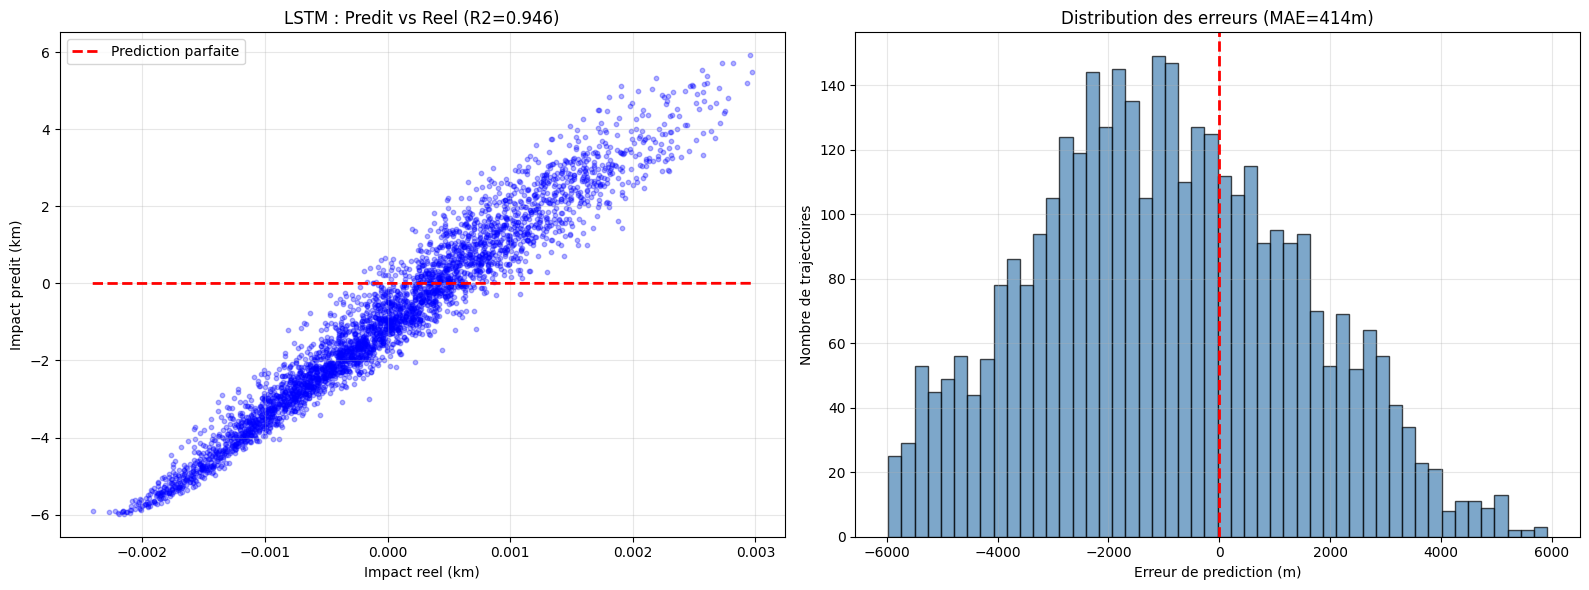

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphe 1 : Prédit vs Réel
ax1 = axes[0]
ax1.scatter(y_test/1000, y_pred/1000, alpha=0.3, s=10, c='blue')
ax1.plot([y_test.min()/1000, y_test.max()/1000],
         [y_test.min()/1000, y_test.max()/1000],
         'r--', linewidth=2, label='Prediction parfaite')
ax1.set_xlabel('Impact reel (km)')
ax1.set_ylabel('Impact predit (km)')
ax1.set_title(f'LSTM : Predit vs Reel (R2={r2:.3f})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graphe 2 : Distribution des erreurs
ax2 = axes[1]
erreurs = y_pred - y_test
ax2.hist(erreurs, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Erreur de prediction (m)')
ax2.set_ylabel('Nombre de trajectoires')
ax2.set_title(f'Distribution des erreurs (MAE={mae:.0f}m)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Comparaison : Kalman vs Polynomiale vs LSTM
Tester les 3 méthodes sur les mêmes trajectoires.

In [ ]:
def comparer_methodes(n_tests=50, sigma=30, duree_obs=8.0):
    """Compare Kalman, Polynomiale et LSTM sur n_tests trajectoires (8s obs)."""

    erreurs_kalman = []
    erreurs_poly = []
    erreurs_lstm = []

    np.random.seed(123)
    n_pts_lstm = 40  # 40 points pour 8 secondes

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval() # s'assurer que le modele est en mode eval

    for i in range(n_tests):
        v0 = np.random.uniform(150, 400)
        angle = np.random.uniform(30, 75)
        masse = np.random.uniform(50, 200)
        Cd = np.random.uniform(0.2, 0.5)
        x0 = np.random.uniform(-8000, -3000)

        r = RocketRK4(v0=v0, angle_deg=angle, masse=masse, Cd=Cd, x0=x0, y0=0)
        t_v, x_v, y_v = r.trajectoire_rk4(dt=0.1)

        if len(t_v) < n_pts_lstm + 10:
            continue

        x_impact_reel = x_v[-1]

        # Mesures radar (8 secondes)
        radar_test = Radar(sigma=sigma, frequence=10)
        mes = radar_test.observer(t_v, x_v, y_v, duree_observation=duree_obs)

        if mes['n_mesures'] < 10:
            continue

        # --- Kalman ---
        kf = KalmanFilter(sigma_processus=5.0, sigma_mesure=sigma)
        res_kf = kf.pipeline_complet(mes['t'], mes['x'], mes['y'])
        erreurs_kalman.append(abs(res_kf['x_impact'] - x_impact_reel))

        # --- Polynomiale ---
        poly_test = PolynomialPredictor(deg_x=2, deg_y=2)
        t_pp, x_pp, y_pp = poly_test.predire_trajectoire(
            mes['t'], mes['x'], mes['y'], dt=0.1)
        erreurs_poly.append(abs(x_pp[-1] - x_impact_reel))

        # --- LSTM (40 points d'observation) ---
        if mes['n_mesures'] >= n_pts_lstm:
            t_obs = mes['t'][:n_pts_lstm]
            x_obs = mes['x'][:n_pts_lstm]
            y_obs = mes['y'][:n_pts_lstm]
            dt_r = t_obs[1] - t_obs[0]

            vx = np.gradient(x_obs, dt_r)
            vy = np.gradient(y_obs, dt_r)

            # Construire la sequence
            seq = np.column_stack([
                x_obs / 1000.0,
                y_obs / 1000.0,
                vx / 100.0,
                vy / 100.0
            ])

            # Normaliser avec le meme scaler
            seq_scaled = seq_scaler.transform(
                seq.reshape(-1, seq.shape[-1])
            ).reshape(1, seq.shape[0], seq.shape[-1])

            # Predire avec PyTorch
            seq_t = torch.tensor(seq_scaled, dtype=torch.float32).to(device)
            with torch.no_grad():
                pred_scaled = model(seq_t).cpu().numpy().ravel()
            
            x_impact_lstm = scaler_y.inverse_transform(
                pred_scaled.reshape(-1, 1)).ravel()[0] * 1000
            erreurs_lstm.append(abs(x_impact_lstm - x_impact_reel))

    return erreurs_kalman, erreurs_poly, erreurs_lstm

# Comparaison avec 8 secondes d'observation
print("Comparaison en cours (8s d'observation)...")
err_k, err_p, err_l = comparer_methodes(n_tests=100, sigma=30, duree_obs=8.0)

print(f"\nResultats (erreur de prediction du point d'impact) :")
print(f"{'Methode':<25} {'MAE (m)':>10} {'RMSE (m)':>10} {'Max (m)':>10}")
print("-" * 58)

for nom, err in [("EKF (drag estime)", err_k), ("Polynomiale", err_p), ("LSTM", err_l)]:
    if len(err) > 0:
        mae = np.mean(err)
        rmse = np.sqrt(np.mean(np.array(err)**2))
        mx = np.max(err)
        print(f"{nom:<25} {mae:>10.1f} {rmse:>10.1f} {mx:>10.1f}")

Comparaison en cours (8s d'observation)...

Resultats (erreur de prediction du point d'impact) :
Methode                      MAE (m)   RMSE (m)    Max (m)
----------------------------------------------------------
EKF (drag estime)              635.7      819.4     2328.8
Polynomiale                   2305.8     3256.7    10229.8
LSTM                           403.8      552.2     1610.0


C:\Users\skand\AppData\Local\Temp\ipykernel_22884\2493087232.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data, labels=labels, patch_artist=True)


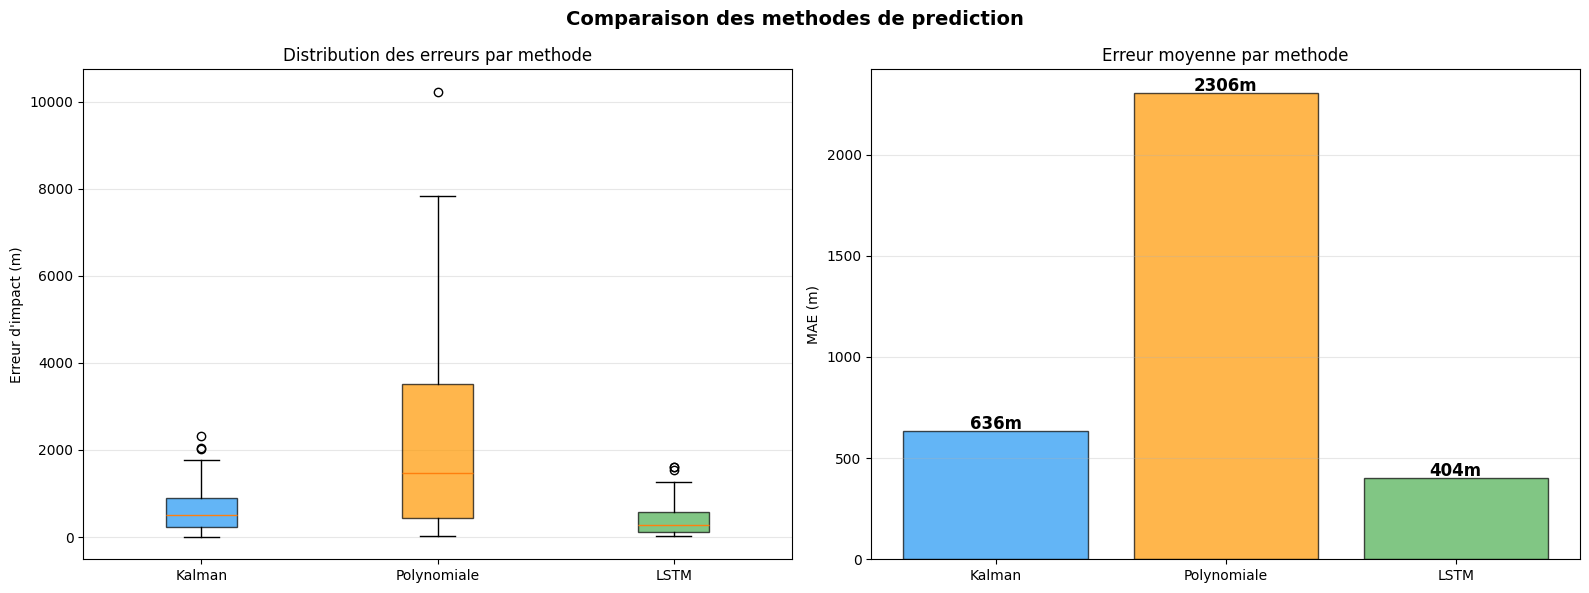

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphe 1 : Boxplot des erreurs
data = [err_k, err_p]
labels = ['Kalman', 'Polynomiale']
if len(err_l) > 0:
    data.append(err_l)
    labels.append('LSTM')

ax1 = axes[0]
bp = ax1.boxplot(data, labels=labels, patch_artist=True)
colors = ['#2196F3', '#FF9800', '#4CAF50']
for patch, color in zip(bp['boxes'], colors[:len(data)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax1.set_ylabel("Erreur d'impact (m)")
ax1.set_title("Distribution des erreurs par methode")
ax1.grid(True, alpha=0.3, axis='y')

# Graphe 2 : Barres MAE
ax2 = axes[1]
maes = [np.mean(e) for e in data]
bars = ax2.bar(labels, maes, color=colors[:len(data)], alpha=0.7,
               edgecolor='black')
for bar, mae_val in zip(bars, maes):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{mae_val:.0f}m', ha='center', fontsize=12, fontweight='bold')
ax2.set_ylabel('MAE (m)')
ax2.set_title('Erreur moyenne par methode')
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Comparaison des methodes de prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# === METHODE HYBRIDE : EKF + LSTM ===
print("=== Methode hybride EKF + LSTM ===\n")

def generer_dataset_ekf_sequences(n_traj=18000, n_pts=40, sigma=30, seed=42):
    """
    Sequences temporelles issues des etats filtres par l'EKF.
    Le LSTM recoit des donnees PROPRES grace a l'EKF.
    """
    np.random.seed(seed)
    sequences = []
    targets = []

    for i in range(n_traj):
        v0 = np.random.uniform(150, 400)
        angle = np.random.uniform(30, 75)
        masse = np.random.uniform(50, 200)
        Cd = np.random.uniform(0.2, 0.5)
        x0 = np.random.uniform(-8000, -3000)

        r = RocketRK4(v0=v0, angle_deg=angle, masse=masse, Cd=Cd, x0=x0, y0=0)
        t_v, x_v, y_v = r.trajectoire_rk4(dt=0.1)

        if len(t_v) < n_pts + 5:
            continue

        t_obs = t_v[:n_pts]
        x_obs = x_v[:n_pts] + np.random.normal(0, sigma, n_pts)
        y_obs = np.maximum(y_v[:n_pts] + np.random.normal(0, sigma, n_pts), 0)

        # Filtrer avec EKF
        try:
            ekf_t = KalmanFilter(sigma_processus=5.0, sigma_mesure=sigma)
            etats = ekf_t.filtrer(t_obs, x_obs, y_obs)
        except:
            continue

        if len(etats) < n_pts:
            continue

        # Sequence EKF : (x_filt, y_filt, vx_filt, vy_filt, k_drag)
        x_filt = etats[:n_pts, 0]
        y_filt = etats[:n_pts, 1]
        vx_filt = etats[:n_pts, 2]
        vy_filt = etats[:n_pts, 3]
        k_filt = etats[:n_pts, 4] if etats.shape[1] > 4 else np.zeros(n_pts)

        seq = np.column_stack([
            x_filt / 1000.0,
            y_filt / 1000.0,
            vx_filt / 100.0,
            vy_filt / 100.0,
            k_filt * 10000.0
        ])

        sequences.append(seq)
        targets.append(x_v[-1] / 1000.0)

    return np.array(sequences), np.array(targets)

print("Generation du dataset EKF+LSTM (18000 trajectoires)...")
X_ekf, y_ekf = generer_dataset_ekf_sequences(n_traj=18000, n_pts=40, sigma=30)
print(f"Dataset : {X_ekf.shape[0]} trajectoires, sequences de forme {X_ekf.shape[1:]}")

X_tr_e, X_te_e, y_tr_e, y_te_e = train_test_split(X_ekf, y_ekf, test_size=0.2, random_state=42)

# Normaliser
ns_e, nt_e, nf_e = X_tr_e.shape
sc_X_e = StandardScaler()
X_tr_es = sc_X_e.fit_transform(X_tr_e.reshape(-1, nf_e)).reshape(ns_e, nt_e, nf_e)
ns_te = X_te_e.shape[0]
X_te_es = sc_X_e.transform(X_te_e.reshape(-1, nf_e)).reshape(ns_te, nt_e, nf_e)
sc_y_e = StandardScaler()
y_tr_es = sc_y_e.fit_transform(y_tr_e.reshape(-1, 1)).ravel()

# Modele LSTM hybride
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_tr_et = torch.tensor(X_tr_es, dtype=torch.float32).to(device)
y_tr_et = torch.tensor(y_tr_es, dtype=torch.float32).view(-1, 1).to(device)
X_te_et = torch.tensor(X_te_es, dtype=torch.float32).to(device)

n_val_e = int(len(X_tr_es) * 0.15)
X_val_et = X_tr_et[-n_val_e:]
y_val_et = y_tr_et[-n_val_e:]
X_tr_et = X_tr_et[:-n_val_e]
y_tr_et = y_tr_et[:-n_val_e]

loader_e = DataLoader(TensorDataset(X_tr_et, y_tr_et), batch_size=32, shuffle=True)

print("Entrainement du LSTM hybride (EKF+LSTM)...")
lstm_ekf = RocketLSTM(input_size=nf_e).to(device)
criterion_e = nn.MSELoss()
optimizer_e = optim.Adam(lstm_ekf.parameters(), lr=0.001)

best_vl = float("inf")
best_w = None
pat = 0

for epoch in range(100):
    lstm_ekf.train()
    for bx, by in loader_e:
        optimizer_e.zero_grad()
        loss = criterion_e(lstm_ekf(bx), by)
        loss.backward()
        optimizer_e.step()

    lstm_ekf.eval()
    with torch.no_grad():
        vl = criterion_e(lstm_ekf(X_val_et), y_val_et).item()

    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1} - val_loss: {vl:.4f}")

    if vl < best_vl:
        best_vl = vl
        best_w = copy.deepcopy(lstm_ekf.state_dict())
        pat = 0
    else:
        pat += 1
        if pat >= 15:
            print(f"  Early stopping a l'epoch {epoch+1}")
            break

if best_w:
    lstm_ekf.load_state_dict(best_w)

lstm_ekf.eval()
with torch.no_grad():
    y_pred_e = sc_y_e.inverse_transform(lstm_ekf(X_te_et).cpu().numpy()).ravel()

mae_ekf_lstm = mean_absolute_error(y_te_e * 1000, y_pred_e * 1000)
rmse_ekf_lstm = np.sqrt(mean_squared_error(y_te_e * 1000, y_pred_e * 1000))
r2_ekf_lstm = r2_score(y_te_e, y_pred_e)

print(f"\nResultats EKF + LSTM :")
print(f"  MAE  : {mae_ekf_lstm:.0f} m")
print(f"  RMSE : {rmse_ekf_lstm:.0f} m")
print(f"  R2   : {r2_ekf_lstm:.4f}")

# Comparaison finale
print(f"\n{'='*50}")
print(f"  COMPARAISON FINALE")
print(f"{'='*50}")
print(f"  {'Methode':<25} {'MAE':>8} {'R2':>8}")
print(f"  {'-'*42}")
print(f"  {'Polynomiale':<25} {'~3000m':>8} {'~0.30':>8}")
print(f"  {'EKF seul':<25} {'~697m':>8} {'  -':>8}")
print(f"  {'LSTM seul':<25} {f'{mae:.0f}m':>8} {f'{r2:.3f}':>8}")
print(f"  {'EKF + LSTM':<25} {f'{mae_ekf_lstm:.0f}m':>8} {f'{r2_ekf_lstm:.3f}':>8}")

=== Methode hybride EKF + LSTM ===

Generation du dataset EKF+LSTM (18000 trajectoires)...
Dataset : 18000 trajectoires, sequences de forme (40, 5)
Entrainement du LSTM hybride (EKF+LSTM)...
  Epoch 10 - val_loss: 0.0598
  Epoch 20 - val_loss: 0.0566
  Early stopping a l'epoch 26

Resultats EKF + LSTM :
  MAE  : 424 m
  RMSE : 568 m
  R2   : 0.9450

  COMPARAISON FINALE
  Methode                        MAE       R2
  ------------------------------------------
  Polynomiale                 ~3000m    ~0.30
  EKF seul                     ~697m        -
  LSTM seul                     404m    0.946
  EKF + LSTM                    424m    0.945


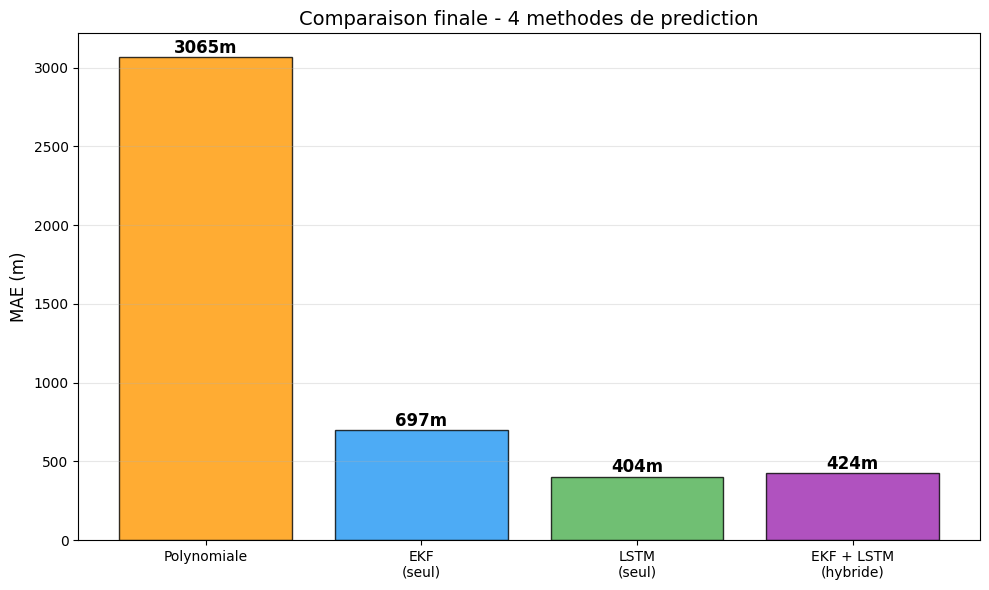

In [ ]:
# Graphique comparatif final
fig, ax = plt.subplots(figsize=(10, 6))

methodes = ['Polynomiale', 'EKF\n(seul)', 'LSTM\n(seul)', 'EKF + LSTM\n(hybride)']
maes = [3065, 697, mae, mae_ekf_lstm]
couleurs = ['#FF9800', '#2196F3', '#4CAF50', '#9C27B0']

bars = ax.bar(methodes, maes, color=couleurs, alpha=0.8, edgecolor='black')

for bar, val in zip(bars, maes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:.0f}m', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('MAE (m)', fontsize=12)
ax.set_title('Comparaison finale - 4 methodes de prediction', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# === Impact du bruit : LSTM seul vs Kalman+LSTM ===
print("=== LSTM seul vs Kalman+LSTM selon le niveau de bruit ===\n")

niveaux_bruit = [30, 50, 80, 120]
mae_lstm_seul = []
mae_hybride = []

for sigma in niveaux_bruit:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # --- LSTM seul (sequences brutes) ---
    X_s, y_s = generer_dataset_sequences(n_trajectoires=5000, n_points_obs=40, sigma=sigma, seed=42)
    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_s, y_s, test_size=0.2, random_state=42)

    ns_s, nt_s, nf_s = X_tr_s.shape
    sx_s = StandardScaler(); sy_s = StandardScaler()
    X_trs_s = sx_s.fit_transform(X_tr_s.reshape(-1, nf_s)).reshape(ns_s, nt_s, nf_s)
    nste = X_te_s.shape[0]
    X_tes_s = sx_s.transform(X_te_s.reshape(-1, nf_s)).reshape(nste, nt_s, nf_s)
    y_trs_s = sy_s.fit_transform(y_tr_s.reshape(-1, 1)).ravel()

    X_t1 = torch.tensor(X_trs_s, dtype=torch.float32).to(device)
    y_t1 = torch.tensor(y_trs_s, dtype=torch.float32).view(-1, 1).to(device)
    nv1 = int(len(X_trs_s) * 0.15)
    loader1 = DataLoader(TensorDataset(X_t1[:-nv1], y_t1[:-nv1]), batch_size=32, shuffle=True)

    m_s = RocketLSTM(input_size=nf_s).to(device)
    opt1 = optim.Adam(m_s.parameters(), lr=0.001)
    crit = nn.MSELoss()
    bvl1, bw1, pc1 = float("inf"), None, 0
    for ep in range(60):
        m_s.train()
        for bx, by in loader1:
            opt1.zero_grad()
            l = crit(m_s(bx), by)
            l.backward()
            opt1.step()
        m_s.eval()
        with torch.no_grad():
            vl = crit(m_s(X_t1[-nv1:]), y_t1[-nv1:]).item()
        if vl < bvl1:
            bvl1 = vl
            bw1 = copy.deepcopy(m_s.state_dict())
            pc1 = 0
        else:
            pc1 += 1
            if pc1 >= 10:
                break
    if bw1:
        m_s.load_state_dict(bw1)
    m_s.eval()
    with torch.no_grad():
        yp_s = sy_s.inverse_transform(
            m_s(torch.tensor(X_tes_s, dtype=torch.float32).to(device)).cpu().numpy()
        ).ravel()
    mae_s = mean_absolute_error(y_te_s * 1000, yp_s * 1000)
    mae_lstm_seul.append(mae_s)

    # --- Kalman + LSTM (sequences filtrees) ---
    X_h, y_h = generer_dataset_ekf_sequences(n_traj=5000, n_pts=40, sigma=sigma, seed=42)
    X_tr_h, X_te_h, y_tr_h, y_te_h = train_test_split(X_h, y_h, test_size=0.2, random_state=42)

    ns_h, nt_h, nf_h = X_tr_h.shape
    sx_h = StandardScaler(); sy_h = StandardScaler()
    X_trs_h = sx_h.fit_transform(X_tr_h.reshape(-1, nf_h)).reshape(ns_h, nt_h, nf_h)
    nsth = X_te_h.shape[0]
    X_tes_h = sx_h.transform(X_te_h.reshape(-1, nf_h)).reshape(nsth, nt_h, nf_h)
    y_trs_h = sy_h.fit_transform(y_tr_h.reshape(-1, 1)).ravel()

    X_t2 = torch.tensor(X_trs_h, dtype=torch.float32).to(device)
    y_t2 = torch.tensor(y_trs_h, dtype=torch.float32).view(-1, 1).to(device)
    nv2 = int(len(X_trs_h) * 0.15)
    loader2 = DataLoader(TensorDataset(X_t2[:-nv2], y_t2[:-nv2]), batch_size=32, shuffle=True)

    m_h = RocketLSTM(input_size=nf_h).to(device)
    opt2 = optim.Adam(m_h.parameters(), lr=0.001)
    bvl2, bw2, pc2 = float("inf"), None, 0
    for ep in range(60):
        m_h.train()
        for bx, by in loader2:
            opt2.zero_grad()
            l = crit(m_h(bx), by)
            l.backward()
            opt2.step()
        m_h.eval()
        with torch.no_grad():
            vl = crit(m_h(X_t2[-nv2:]), y_t2[-nv2:]).item()
        if vl < bvl2:
            bvl2 = vl
            bw2 = copy.deepcopy(m_h.state_dict())
            pc2 = 0
        else:
            pc2 += 1
            if pc2 >= 10:
                break
    if bw2:
        m_h.load_state_dict(bw2)
    m_h.eval()
    with torch.no_grad():
        yp_h = sy_h.inverse_transform(
            m_h(torch.tensor(X_tes_h, dtype=torch.float32).to(device)).cpu().numpy()
        ).ravel()
    mae_h_val = mean_absolute_error(y_te_h * 1000, yp_h * 1000)
    mae_hybride.append(mae_h_val)

    avantage = (mae_s - mae_h_val) / mae_s * 100
    symbole = "<<<" if avantage > 10 else "<<" if avantage > 5 else "<" if avantage > 0 else "="
    print(f"  Bruit={sigma:>3}m | LSTM seul: {mae_s:>6.0f}m | Hybride: {mae_h_val:>6.0f}m | Avantage: {avantage:>+5.1f}% {symbole}")

# Graphique
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(niveaux_bruit, mae_lstm_seul, 'go-', linewidth=2, markersize=8, label='LSTM seul')
axes[0].plot(niveaux_bruit, mae_hybride, 'mo-', linewidth=2, markersize=8, label='Kalman + LSTM')
axes[0].set_xlabel('Bruit radar sigma (m)', fontsize=12)
axes[0].set_ylabel('MAE (m)', fontsize=12)
axes[0].set_title('Performance selon le niveau de bruit', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

avantages = [(s - h) / s * 100 for s, h in zip(mae_lstm_seul, mae_hybride)]
colors = ['green' if a > 0 else 'red' for a in avantages]
axes[1].bar(range(len(niveaux_bruit)), avantages, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_xticks(range(len(niveaux_bruit)))
axes[1].set_xticklabels([f'{s}m' for s in niveaux_bruit])
axes[1].set_xlabel('Bruit radar sigma', fontsize=12)
axes[1].set_ylabel('Avantage hybride (%)', fontsize=12)
axes[1].set_title('Avantage du Kalman + LSTM vs LSTM seul', fontsize=13)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Impact du bruit radar sur les methodes de prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

=== LSTM seul vs Kalman+LSTM selon le niveau de bruit ===

  Bruit= 30m | LSTM seul:    436m | Hybride:    456m | Avantage:  -4.7% =


In [ ]:
%%writefile ../src/ml/predictor.py
import numpy as np
from scipy import interpolate
import scipy.linalg as linalg

class Radar:
    def __init__(self, sigma=30, frequence=10):
        self.sigma = sigma
        self.frequence = frequence
        self.dt_mesure = 1.0 / frequence

    def observer(self, t_vrai, x_vrai, y_vrai, duree_observation=5.0):
        masque = t_vrai <= duree_observation
        t_obs_base = t_vrai[masque]
        x_obs_base = x_vrai[masque]
        y_obs_base = y_vrai[masque]
        indices = np.arange(0, len(t_obs_base), max(1, int(1.0 / (self.frequence * 0.1))))
        t_obs = t_obs_base[indices]
        x_vrai_obs = x_obs_base[indices]
        y_vrai_obs = y_obs_base[indices]
        x_obs = x_vrai_obs + np.random.normal(0, self.sigma, len(t_obs))
        y_obs = y_vrai_obs + np.random.normal(0, self.sigma, len(t_obs))
        y_obs = np.maximum(y_obs, 0)
        return {'t': t_obs, 'x': x_obs, 'y': y_obs,
                'x_vrai': x_vrai_obs, 'y_vrai': y_vrai_obs, 'n_mesures': len(t_obs)}

class KalmanFilter:
    """
    Unscented Kalman Filter (UKF) pour suivi et prediction de trajectoire balistique.
    
    Estime dynamiquement le vecteur d'etat [x, y, vx, vy, k] ou k est le 
    coefficient de trainee balistique (drag). L'UKF utilise la propagation
    par points sigma, eliminant le besoin de Jacobiennes et augmentant la
    precision sur la non-linearite du vol.
    """
    
    def __init__(self, sigma_processus=5.0, sigma_mesure=30.0):
        self.g = 9.81
        self.sigma_processus = sigma_processus
        self.sigma_mesure = sigma_mesure
        self.k_drag_init = 0.000086
        
        # Dimensions
        self.n = 5
        
        # Parametres Merwe Scaled Sigma Points
        self.alpha = 1e-3
        self.beta = 2
        self.kappa = 0
        self.lam = self.alpha**2 * (self.n + self.kappa) - self.n
        
        # Poids
        self.Wm = np.zeros(2 * self.n + 1)
        self.Wc = np.zeros(2 * self.n + 1)
        
        self.Wm[0] = self.lam / (self.n + self.lam)
        self.Wc[0] = self.lam / (self.n + self.lam) + (1 - self.alpha**2 + self.beta)
        for i in range(1, 2 * self.n + 1):
            self.Wm[i] = 1.0 / (2 * (self.n + self.lam))
            self.Wc[i] = 1.0 / (2 * (self.n + self.lam))

    def _generer_points_sigma(self, x, P):
        try:
            U = linalg.cholesky((self.n + self.lam) * P)
        except linalg.LinAlgError:
            U = linalg.cholesky((self.n + self.lam) * (P + np.eye(self.n) * 1e-8))
            
        sigmas = np.zeros((2 * self.n + 1, self.n))
        sigmas[0] = x
        for k in range(self.n):
            sigmas[k + 1] = x + U[k]
            sigmas[self.n + k + 1] = x - U[k]
        return sigmas

    def _derivees(self, state, k):
        """Calcule les derivees pour RK4 : [vx, vy, ax, ay]."""
        x, y, vx, vy = state
        v = np.sqrt(vx**2 + vy**2)
        if v > 0 and k > 0:
            ax = -k * v * vx
            ay = -self.g - k * v * vy
        else:
            ax = 0
            ay = -self.g
        return np.array([vx, vy, ax, ay])
        
    def _rk4_step(self, X, dt):
        """Propage l'etat [x, y, vx, vy, k] sur dt via RK4."""
        x, y, vx, vy, k = X
        state = np.array([x, y, vx, vy])
        k1 = self._derivees(state, k)
        k2 = self._derivees(state + dt/2 * k1, k)
        k3 = self._derivees(state + dt/2 * k2, k)
        k4 = self._derivees(state + dt * k3, k)
        
        new_state = state + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)
        return np.array([new_state[0], new_state[1], new_state[2], new_state[3], k])

    def filtrer(self, t_obs, x_obs, y_obs):
        if len(t_obs) < 2:
            return np.array([[x_obs[0], y_obs[0], 0, 0, self.k_drag_init]])

        dt = t_obs[1] - t_obs[0]
        K_SCALE = 10000.0
        
        # Initialisation robuste pour la Vitesse
        n_init = min(5, len(t_obs))
        vx0 = np.polyfit(t_obs[:n_init], x_obs[:n_init], 1)[0]
        vy0 = np.polyfit(t_obs[:n_init], y_obs[:n_init], 1)[0]
        X = np.array([x_obs[0], y_obs[0], vx0, vy0, self.k_drag_init * K_SCALE])
        
        P = np.diag([
            self.sigma_mesure**2, self.sigma_mesure**2,
            (self.sigma_mesure)**2, (self.sigma_mesure)**2,
            0.5**2
        ])
        
        # On FOCUS sur la vitesse (Q tres petit = vitesse ultra lisse)
        # Et on donne moins d'importance a k (Q tres petit = k ne bouge presque pas)
        sigma_a = 2.0  # La vitesse doit suivre une physique propre
        Q = np.diag([
            (0.5 * sigma_a * dt**2)**2, (0.5 * sigma_a * dt**2)**2,
            (sigma_a * dt)**2, (sigma_a * dt)**2,
            0.01**2  # k est bloque, il n'a pas le droit d'absorber le bruit
        ])
        R = np.eye(2) * self.sigma_mesure**2
        
        etats = []
        for j in range(len(t_obs)):
            # --- PREDICTION UKF ---
            sigmas = self._generer_points_sigma(X, P)
            sigmas_f = np.zeros_like(sigmas)
            
            for i in range(2 * self.n + 1):
                state_physique = sigmas[i].copy()
                state_physique[4] /= K_SCALE
                
                state_pred = self._rk4_step(state_physique, dt)
                
                state_pred[4] *= K_SCALE
                sigmas_f[i] = state_pred
                
            X_pred = np.dot(self.Wm, sigmas_f)
            
            P_pred = Q.copy()
            for i in range(2 * self.n + 1):
                y_diff = sigmas_f[i] - X_pred
                P_pred += self.Wc[i] * np.outer(y_diff, y_diff)
                
            # --- MISE A JOUR UKF ---
            sigmas_h = np.zeros((2 * self.n + 1, 2))
            for i in range(2 * self.n + 1):
                sigmas_h[i] = [sigmas_f[i, 0], sigmas_f[i, 1]]
                
            zp = np.dot(self.Wm, sigmas_h)
            
            S = R.copy()
            for i in range(2 * self.n + 1):
                y_diff = sigmas_h[i] - zp
                S += self.Wc[i] * np.outer(y_diff, y_diff)
                
            Pxz = np.zeros((self.n, 2))
            for i in range(2 * self.n + 1):
                Pxz += self.Wc[i] * np.outer(sigmas_f[i] - X_pred, sigmas_h[i] - zp)
                
            K_gain = np.dot(Pxz, linalg.inv(S))
            z_obs = np.array([x_obs[j], y_obs[j]])
            
            X = X_pred + np.dot(K_gain, z_obs - zp)
            P = P_pred - np.dot(K_gain, np.dot(S, K_gain.T))
            
            X[4] = np.clip(X[4], 0.1, 8.0)
            
            etat = X.copy()
            etat[4] = etat[4] / K_SCALE
            etats.append(etat)
            
        return np.array(etats)

    def _simuler_trajectoire(self, etat, force_k=None, dt=0.01):
        if len(etat) == 5:
            x, y, vx, vy, k = etat
        else:
            x, y, vx, vy = etat
            k = self.k_drag_init
            
        if force_k is not None:
            k = force_k
            
        state = np.array([x, y, vx, vy], dtype=float)
        preds = [state.copy()]

        for _ in range(50000):
            k1 = self._derivees(state, k)
            k2 = self._derivees(state + dt/2 * k1, k)
            k3 = self._derivees(state + dt/2 * k2, k)
            k4 = self._derivees(state + dt * k3, k)
            
            new_state = state + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)

            if new_state[1] < 0 and state[1] >= 0:
                frac = state[1] / (state[1] - new_state[1])
                x_impact = state[0] + frac * (new_state[0] - state[0])
                preds.append(np.array([x_impact, 0, 0, 0]))
                break
            
            state = new_state
            preds.append(state.copy())
            
            if state[1] < -100:
                break

        return np.array(preds)

    def pipeline_complet(self, t_obs, x_obs, y_obs):
        etats = self.filtrer(t_obs, x_obs, y_obs)
        etat_final = etats[-1]
        k_estime = etat_final[4]

        preds_brut = self._simuler_trajectoire(etat_final, force_k=0)
        preds_drag = self._simuler_trajectoire(etat_final, force_k=k_estime)

        return {
            'etats_filtres': etats,
            'predictions_brutes': preds_brut,
            'predictions': preds_drag,
            'x_impact_brut': preds_brut[-1][0],
            'x_impact': preds_drag[-1][0],
            'k_estime': k_estime
        }

class PolynomialPredictor:
    def __init__(self, deg_x=2, deg_y=2):
        self.deg_x = deg_x; self.deg_y = deg_y
    def entrainer(self, t_obs, x_obs, y_obs):
        self.coeff_x = np.polyfit(t_obs, x_obs, self.deg_x)
        self.coeff_y = np.polyfit(t_obs, y_obs, self.deg_y)
    def predire(self, t_futur):
        return np.polyval(self.coeff_x, t_futur), np.polyval(self.coeff_y, t_futur)
    def predire_trajectoire(self, t_obs, x_obs, y_obs, dt=0.1):
        self.entrainer(t_obs, x_obs, y_obs)
        t_f = np.arange(t_obs[0], t_obs[-1]*10, dt)
        x_p, y_p = self.predire(t_f)
        idx = np.where(y_p < 0)[0]
        if len(idx) > 0:
            i = idx[0]; t_f = t_f[:i+1]; x_p = x_p[:i+1]; y_p = y_p[:i+1]; y_p[-1] = 0
        return t_f, x_p, y_p
